<a href="https://colab.research.google.com/github/oliviatawakol/julieandliv/blob/main/julieandliv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Cost of College and Enrollment Inequality in the United States**

**Names:** Julie Atkeson and Olivia Tawakol

GitHub Pages Link: (insert once published)

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

# Display all columns when previewing data
pd.set_option("display.max_columns", None)


## **Project Goals**

This project aims to examine how the rising cost of college affects who is able to enroll in higher education in the United States. Over the past several decades, tuition costs have increased significantly while household incomes have grown much more slowly. As a result, many students, particularly those from lower and middle-income families, may face financial barriers when deciding whether to attend college.
Our project aims to explore the relationship between family income, tuition costs, and college enrollment. Specifically, we want to better understand whether students from higher-income households are more likely to enroll in college and whether financial aid programs help make college more accessible to students from lower income backgrounds. By combining multiple datasets, we hope to identify trends in college affordability and determine which groups of students may be disproportionately affected by rising costs.
Some of the key questions we hope to explore include:
How have tuition prices changed over time across different types of institutions (public vs. private, two-year vs. four-year)?



*   How have tuition prices changed over time across different types of institutions (public vs. private, two-year vs. four-year)?

*   Are college enrollment rates different for students from different income levels?
*   Does financial aid appear to reduce barriers to college access?


*   Which groups of students appear to be most affected by rising tuition costs?

To answer these questions, we will analyze several publicly available datasets related to tuition, household income, and college enrollment.


## **Collaboration Plan**

Our team will meet weekly to coordinate progress, review each other's work, and discuss next steps in the project. Between meetings, we will communicate through text messages to share updates and ask questions as they arise. We will maintain a shared notes document to track tasks and ideas throughout the project. All code will be developed collaboratively in a shared Google Colab notebook, which allows both team members to contribute to the analysis and review changes easily. This approach ensures that both members remain actively involved in the data processing, analysis, and visualization stages of the project.


## **Data Sources**

# Dataset 1: U.S. Census Current Population Survey (CPS)

**Source:** https://www.census.gov/data/datasets/time-series/demo/cps/cps-asec.html

This dataset provides detailed demographic and economic information about households in the United States, including variables related to income and school enrollment. The full CPS dataset contains hundreds of variables, so for this milestone we focus only on the columns needed to analyze the relationship between **household income and college enrollment**.

### Key Question

**Are students from higher income households more likely to enroll in college?**

This dataset is important to our project because it allows us to compare enrollment patterns across income categories. If college enrollment rises as income rises, that would suggest that financial resources may play a significant role in access to higher education.



In [ ]:
# Load only the columns needed for this analysis
income_gap_df = pd.read_csv(
    "uscensus.csv",
    usecols=["PH_SEQ", "PTOT_R", "A_HSCOL"]
)

# Preview the raw subset
income_gap_df.head()

,PH_SEQ,A_HSCOL,PTOT_R
0,1,0,10
1,1,0,1
2,10,0,7
3,11,0,8
4,13,0,41


## Tidy Data / Cleaning

To make the CPS data tidy and manageable, we keep only the three variables that are relevant to our research question:

- `PH_SEQ` = household identifier  
- `PTOT_R` = total household income bracket  
- `A_HSCOL` = enrollment status  

We then rename these columns for clarity, check for missing values, convert the key variables to numeric format, remove invalid or missing observations, and create a binary variable indicating whether an individual is enrolled in college.

These cleaning steps are important because they ensure that the analysis is based only on observations that meaningfully relate to the research question.

In [ ]:
# Rename important columns for clarity
income_gap_df = income_gap_df.rename(columns={
    "PH_SEQ": "household_id",
    "PTOT_R": "total_income_bracket",
    "A_HSCOL": "enrollment_status"
})

# Check missing values and data types before cleaning
print("Missing values before cleaning:")
print(income_gap_df.isna().sum())

print("\nData types before cleaning:")
print(income_gap_df.dtypes)

Missing values before cleaning:
household_id            0
enrollment_status       0
total_income_bracket    0
dtype: int64

Data types before cleaning:
household_id            int64
enrollment_status       int64
total_income_bracket    int64
dtype: object


In [ ]:
# Drop rows with missing values in the variables needed for analysis
income_gap_df = income_gap_df.dropna(subset=["total_income_bracket", "enrollment_status"])

# Convert key variables to numeric to ensure proper data types
income_gap_df["total_income_bracket"] = pd.to_numeric(
    income_gap_df["total_income_bracket"], errors="coerce"
)
income_gap_df["enrollment_status"] = pd.to_numeric(
    income_gap_df["enrollment_status"], errors="coerce"
)

# Drop rows that became missing after conversion
income_gap_df = income_gap_df.dropna(subset=["total_income_bracket", "enrollment_status"])

# Keep rows where enrollment status matches the categories used in this project
enrolled_df = income_gap_df[income_gap_df["enrollment_status"].isin([1, 2])].copy()

# Keep only valid positive income brackets
enrolled_df = enrolled_df[enrolled_df["total_income_bracket"] > 0]

# Create binary variable: 1 = enrolled in college, 0 = not enrolled in college
enrolled_df["college_enrolled"] = (enrolled_df["enrollment_status"] == 2).astype(int)

# Sort by income bracket for readability
enrolled_df = enrolled_df.sort_values("total_income_bracket").reset_index(drop=True)

# Preview cleaned dataset
enrolled_df.head()

,household_id,enrollment_status,total_income_bracket,college_enrolled
0,68932,1,1,0
1,37215,1,1,0
2,37345,2,1,1
3,37345,1,1,0
4,37363,1,1,0


In [ ]:
# Display missing values and dtypes after cleaning
print("Missing values after cleaning:")
print(enrolled_df[["household_id", "total_income_bracket", "enrollment_status", "college_enrolled"]].isna().sum())

print("\nData types after cleaning:")
print(enrolled_df[["household_id", "total_income_bracket", "enrollment_status", "college_enrolled"]].dtypes)

Missing values after cleaning:
household_id            0
total_income_bracket    0
enrollment_status       0
college_enrolled        0
dtype: int64

Data types after cleaning:
household_id            int64
total_income_bracket    int64
enrollment_status       int64
college_enrolled        int64
dtype: object


After cleaning, the dataset is in a tidy format where:

- Each row represents one observation
- Each column represents one variable
- Income and enrollment variables are stored as numeric values
- Rows with missing or invalid values have been removed
- A new binary `college_enrolled` variable has been created

This cleaned structure allows us to calculate enrollment rates by income bracket and visualize how college participation changes across income levels.

## Exploratory Data Analysis

To explore the relationship between income and college enrollment, we calculate the average college enrollment rate within each income bracket. This allows us to compare how likely individuals are to be enrolled in college across different levels of household income.

In [ ]:
# Calculate average college enrollment rate by income bracket
enrollment_by_income = (
    enrolled_df.groupby("total_income_bracket")["college_enrolled"]
    .mean()
    .reset_index()
)

# Rename the calculated column for clarity
enrollment_by_income.columns = ["total_income_bracket", "college_enrollment_rate"]

# Display grouped results
enrollment_by_income

,total_income_bracket,college_enrollment_rate
0,1,0.310084
1,2,0.463884
2,3,0.569640
3,4,0.621253
4,5,0.617284
5,6,0.664122
6,7,0.760252
7,8,0.847458
8,9,0.868902
9,10,0.864583


In [ ]:
# Summary statistics for college enrollment rates by income bracket
print("Summary statistics of college enrollment rates by income bracket:")
print(enrollment_by_income["college_enrollment_rate"].describe())

print("\nLowest enrollment rate:", enrollment_by_income["college_enrollment_rate"].min())
print("Highest enrollment rate:", enrollment_by_income["college_enrollment_rate"].max())
print("Average enrollment rate:", enrollment_by_income["college_enrollment_rate"].mean())
print("Median enrollment rate:", enrollment_by_income["college_enrollment_rate"].median())

# Compare low-income and high-income groups
bottom_5_avg = enrollment_by_income.nsmallest(5, "total_income_bracket")["college_enrollment_rate"].mean()
top_5_avg = enrollment_by_income.nlargest(5, "total_income_bracket")["college_enrollment_rate"].mean()

# Calculate the gap and correlation
enrollment_gap = (
    enrollment_by_income["college_enrollment_rate"].max()
    - enrollment_by_income["college_enrollment_rate"].min()
)

income_enrollment_corr = enrollment_by_income["total_income_bracket"].corr(
    enrollment_by_income["college_enrollment_rate"]
)

print("\nAverage enrollment rate in bottom 5 income brackets:", bottom_5_avg)
print("Average enrollment rate in top 5 income brackets:", top_5_avg)
print("Gap between highest and lowest enrollment rates:", enrollment_gap)
print("Correlation between income bracket and enrollment rate:", income_enrollment_corr)

Summary statistics of college enrollment rates by income bracket:
count    41.000000
mean      0.891585
std       0.161911
min       0.310084
25%       0.903930
50%       0.956522
75%       0.982143
max       1.000000
Name: college_enrollment_rate, dtype: float64

Lowest enrollment rate: 0.3100843288826423
Highest enrollment rate: 1.0
Average enrollment rate: 0.8915853267606165
Median enrollment rate: 0.9565217391304348

Average enrollment rate in bottom 5 income brackets: 0.5164292356537701
Average enrollment rate in top 5 income brackets: 0.9679180509413067
Gap between highest and lowest enrollment rates: 0.6899156711173577
Correlation between income bracket and enrollment rate: 0.7420581758795372


## Summary Statistics Interpretation

Several statistics from Dataset 1 are especially relevant to our research question.

The **lowest enrollment rate** is about **31.0%**, while the **highest enrollment rate** reaches **100.0%** in several of the highest income brackets in this sample. This suggests that access to college is not evenly distributed across income levels.

The **average enrollment rate across the bottom five income brackets** is about **51.6%**, while the **average across the top five income brackets** is about **96.8%**. This means students in the highest income categories in this sample are enrolled in college at nearly **double the rate** of those in the lowest categories.

The **gap between the highest and lowest enrollment rates** is about **68.99 percentage points**, which highlights the magnitude of the inequality in college enrollment.

Finally, the **correlation between income bracket and enrollment rate** is approximately **0.742**, indicating a strong positive relationship between household income and college enrollment.

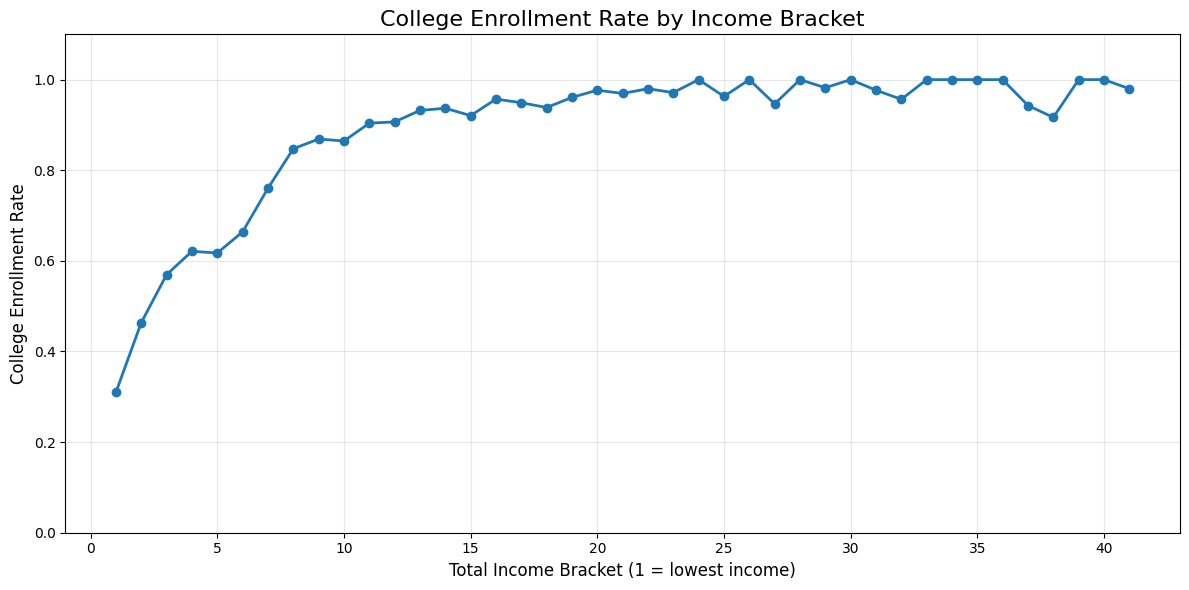

In [ ]:
# Visualize enrollment rate by income bracket
plt.figure(figsize=(12, 6))

plt.plot(
    enrollment_by_income["total_income_bracket"],
    enrollment_by_income["college_enrollment_rate"],
    marker="o",
    linewidth=2
)

plt.title("College Enrollment Rate by Income Bracket", fontsize=16)
plt.xlabel("Total Income Bracket (1 = lowest income)", fontsize=12)
plt.ylabel("College Enrollment Rate", fontsize=12)

plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualization Explanation

The line chart shows a clear upward trend: as household income bracket increases, college enrollment rates generally increase as well.

Enrollment begins at about **31% in the lowest income bracket** and rises to values above **90% across many higher-income brackets**. This pattern suggests that college access may be closely tied to family financial resources.

This visualization is directly relevant to our research question because it clearly demonstrates that students from higher-income households are significantly more likely to enroll in college.

# Dataset 2: College Scorecard

**Source:** https://collegescorecard.ed.gov/data/

The College Scorecard dataset contains detailed information about colleges and universities in the United States, including tuition costs, total cost of attendance, net price after financial aid, Pell Grant participation, and student borrowing rates.

### Key Question

**Do institutions with higher tuition costs provide enough financial aid to maintain access for lower-income students?**

This dataset is useful because it allows us to compare the **sticker price of college**, the **net price students actually pay**, and **financial aid indicators** across thousands of institutions.

In [ ]:
# Load College Scorecard data
scorecard_df = pd.read_csv(
    "collegescorecard.csv",
    low_memory=False,
    na_values=["PS", "PrivacySuppressed", "NULL", "NA"]
)

# Preview basic structure
print(scorecard_df.shape)
print(scorecard_df.columns[:10].tolist())
print(scorecard_df[["INSTNM", "CONTROL", "TUITIONFEE_OUT", "NPT4_PUB", "NPT4_PRIV", "PCTPELL"]].head(3))

(6429, 3306)
['UNITID', 'OPEID', 'OPEID6', 'INSTNM', 'CITY', 'STABBR', 'ZIP', 'ACCREDAGENCY', 'INSTURL', 'NPCURL']
                                INSTNM  CONTROL  TUITIONFEE_OUT  NPT4_PUB  \
0             Alabama A & M University        1         18634.0   14559.0   
1  University of Alabama at Birmingham        1         21864.0   17727.0   
2                   Amridge University        2             NaN       NaN   

   NPT4_PRIV  PCTPELL  
0        NaN   0.6441  
1        NaN   0.3318  
2        NaN   0.6842  


## Tidy Data / Cleaning

The full College Scorecard dataset contains thousands of variables, so we select only the columns relevant to our research question.

We then:

- keep only 2-year and 4-year degree-granting institutions
- remove rows missing key cost and aid variables
- create consistent institution type labels
- combine public and private net price measures
- calculate an aid discount variable
- group schools into tuition quartiles

These steps make the dataset easier to analyze and ensure the variables directly relate to the affordability question we are exploring.

In [ ]:
# Select relevant variables for analysis
cols = [
    "UNITID", "INSTNM", "CONTROL", "STABBR", "PREDDEG", "HIGHDEG",
    "TUITIONFEE_IN", "TUITIONFEE_OUT", "COSTT4_A",
    "NPT4_PUB", "NPT4_PRIV",
    "NPT41_PUB", "NPT42_PUB", "NPT43_PUB", "NPT44_PUB", "NPT45_PUB",
    "NPT41_PRIV", "NPT42_PRIV", "NPT43_PRIV", "NPT44_PRIV", "NPT45_PRIV",
    "PCTPELL", "PCTFLOAN_DCS", "UGDS"
]

df = scorecard_df[cols].copy()

# Keep only 2-year and 4-year degree-granting institutions
df = df[df["PREDDEG"].isin([2, 3])]

# Drop rows missing key overall cost and aid variables
df = df.dropna(subset=["COSTT4_A", "PCTPELL"])

# Label institution type
df["inst_type"] = df["CONTROL"].map({
    1: "Public",
    2: "Private Nonprofit",
    3: "Private For-Profit"
})

# Create unified overall net price column
df["NPT4"] = df["NPT4_PUB"].fillna(df["NPT4_PRIV"])

# Create unified lowest-income net price column
df["NPT41"] = df["NPT41_PUB"].fillna(df["NPT41_PRIV"])

# Aid generosity = total cost minus net price for lowest-income students
df["aid_gap"] = df["COSTT4_A"] - df["NPT41"]

# Create tuition quartiles
df["tuition_quartile"] = pd.qcut(
    df["COSTT4_A"],
    q=4,
    labels=["Q1\n(Lowest)", "Q2", "Q3", "Q4\n(Highest)"]
)

# Check missing values and dtypes in cleaned subset
print("Missing values after cleaning:")
print(df[["inst_type", "COSTT4_A", "NPT41", "PCTPELL", "aid_gap"]].isna().sum())

print("\nData types after cleaning:")
print(df[["inst_type", "COSTT4_A", "NPT41", "PCTPELL", "aid_gap", "UGDS"]].dtypes)

print("\nCleaned dataset shape:")
print(df.shape)

df.head()

Missing values after cleaning:
inst_type     0
COSTT4_A      0
NPT41        50
PCTPELL       0
aid_gap      50
dtype: int64

Data types after cleaning:
inst_type     object
COSTT4_A     float64
NPT41        float64
PCTPELL      float64
aid_gap      float64
UGDS         float64
dtype: object

Cleaned dataset shape:
(2702, 29)


,UNITID,INSTNM,CONTROL,STABBR,PREDDEG,HIGHDEG,TUITIONFEE_IN,TUITIONFEE_OUT,COSTT4_A,NPT4_PUB,NPT4_PRIV,NPT41_PUB,NPT42_PUB,NPT43_PUB,NPT44_PUB,NPT45_PUB,NPT41_PRIV,NPT42_PRIV,NPT43_PRIV,NPT44_PRIV,NPT45_PRIV,PCTPELL,PCTFLOAN_DCS,UGDS,inst_type,NPT4,NPT41,aid_gap,tuition_quartile
0,100654,Alabama A & M University,1,AL,3,4,10024.0,18634.0,23751.0,14559.0,NaN,13776.0,13923.0,16471.0,19057.0,18200.0,NaN,NaN,NaN,NaN,NaN,0.6441,0.5864,5726.0,Public,14559.0,13776.0,9975.0,Q2
1,100663,University of Alabama at Birmingham,1,AL,3,4,8832.0,21864.0,27826.0,17727.0,NaN,14816.0,15876.0,18310.0,20913.0,21326.0,NaN,NaN,NaN,NaN,NaN,0.3318,0.4179,12118.0,Public,17727.0,14816.0,13010.0,Q3
3,100706,University of Alabama in Huntsville,1,AL,3,4,11770.0,24662.0,27098.0,19880.0,NaN,16521.0,17935.0,21187.0,21205.0,21937.0,NaN,NaN,NaN,NaN,NaN,0.2250,0.3477,6650.0,Public,19880.0,16521.0,10577.0,Q3
4,100724,Alabama State University,1,AL,3,4,11248.0,19576.0,22028.0,13889.0,NaN,13512.0,14047.0,15155.0,15771.0,11863.0,NaN,NaN,NaN,NaN,NaN,0.7203,0.7776,3322.0,Public,13889.0,13512.0,8516.0,Q2
5,100751,The University of Alabama,1,AL,3,4,11900.0,33200.0,32024.0,22150.0,NaN,18592.0,19928.0,23056.0,25396.0,25773.0,NaN,NaN,NaN,NaN,NaN,0.1799,0.3474,32323.0,Public,22150.0,18592.0,13432.0,Q3


After cleaning, Dataset 2 is in a tidy format where each row represents one institution and each column represents one variable relevant to cost, aid, or access. Missing values still remain in some net price variables because not all schools report every measure, but the cleaned subset is sufficient for milestone-level exploratory analysis.

## Exploratory Data Analysis

We use three summary views to understand whether expensive institutions offset their higher costs enough to remain accessible to lower-income students.

In [ ]:
# STAT 1: Average net price for lowest-income students by institution type
print("=" * 60)
print("STAT 1: Avg Net Price for Lowest-Income Students (0-$30k)")
print("        by Institution Type")
print("=" * 60)

stat1 = df.groupby("inst_type")["NPT41"].agg(["mean", "median", "count"])
stat1.columns = ["Mean Net Price", "Median Net Price", "N"]

stat1_display = stat1.copy()
stat1_display["Mean Net Price"] = stat1_display["Mean Net Price"].map('${:,.0f}'.format)
stat1_display["Median Net Price"] = stat1_display["Median Net Price"].map('${:,.0f}'.format)

print(stat1_display.to_string())

STAT 1: Avg Net Price for Lowest-Income Students (0-$30k)
        by Institution Type
                   Mean Net Price Median Net Price     N
inst_type                                               
Private For-Profit        $24,975          $23,896   202
Private Nonprofit         $17,649          $17,482  1205
Public                     $8,075           $7,896  1245


This statistic is relevant because it compares what the **lowest-income students actually pay** at different types of institutions, rather than just comparing sticker prices.

Public institutions have an average low-income net price of about **\$8,075**, compared with **\$17,649** at private nonprofit schools and **\$24,975** at private for-profit schools. This means that, even after aid, the average low-income student still faces a much larger financial burden at private institutions than at public institutions. This supports the idea that institution type plays a major role in affordability.

In [ ]:
# STAT 2: Average cost, net price, and Pell share by tuition quartile
print("\n" + "=" * 60)
print("STAT 2: Avg Cost of Attendance, Low-Income Net Price, and Pell %")
print("        by Tuition Quartile")
print("=" * 60)

stat2 = df.groupby("tuition_quartile", observed=True).agg(
    Avg_Cost=("COSTT4_A", "mean"),
    Avg_NetPrice_LoIncome=("NPT41", "mean"),
    Avg_PctPell=("PCTPELL", "mean"),
    N=("UNITID", "count")
).round(0)

stat2_display = stat2.copy()
stat2_display["Avg_Cost"] = stat2_display["Avg_Cost"].map('${:,.0f}'.format)
stat2_display["Avg_NetPrice_LoIncome"] = stat2_display["Avg_NetPrice_LoIncome"].map('${:,.0f}'.format)
stat2_display["Avg_PctPell"] = (stat2["Avg_PctPell"] * 100).map('{:.1f}%'.format)

print(stat2_display.to_string())


STAT 2: Avg Cost of Attendance, Low-Income Net Price, and Pell %
        by Tuition Quartile
                 Avg_Cost Avg_NetPrice_LoIncome Avg_PctPell    N
tuition_quartile                                                
Q1\n(Lowest)      $13,568                $5,370        0.0%  676
Q2                $21,770               $10,980        0.0%  675
Q3                $33,700               $17,935        0.0%  675
Q4\n(Highest)     $60,424               $20,635        0.0%  676


This grouped summary is important because it shows whether more expensive schools actually become affordable after aid is applied.

The results suggest they do not fully offset their higher sticker prices. The average cost of attendance rises from about **\$13,568** in the lowest tuition quartile to **\$60,424** in the highest quartile. At the same time, the average net price for the lowest-income students rises from about **\$5,370** to **\$20,635**. That means the actual price paid by lower-income students is almost **four times higher** at the most expensive schools than at the least expensive schools.

In [ ]:
# STAT 3: Aid generosity by tuition quartile
print("\n" + "=" * 60)
print("STAT 3: Aid Generosity — Avg Grant Aid to Lowest-Income Students")
print("        (Cost of Attendance minus Net Price, by Tuition Quartile)")
print("=" * 60)

stat3 = df.groupby("tuition_quartile", observed=True)["aid_gap"].agg(["mean", "median"]).round(0)
stat3.columns = ["Mean Aid Gap", "Median Aid Gap"]

stat3_display = stat3.copy()
stat3_display["Mean Aid Gap"] = stat3_display["Mean Aid Gap"].map('${:,.0f}'.format)
stat3_display["Median Aid Gap"] = stat3_display["Median Aid Gap"].map('${:,.0f}'.format)

print(stat3_display.to_string())


STAT 3: Aid Generosity — Avg Grant Aid to Lowest-Income Students
        (Cost of Attendance minus Net Price, by Tuition Quartile)
                 Mean Aid Gap Median Aid Gap
tuition_quartile                            
Q1\n(Lowest)           $8,186         $7,898
Q2                    $10,787        $10,439
Q3                    $15,745        $15,412
Q4\n(Highest)         $39,819        $36,198


This statistic measures how much institutions discount their total cost for lower-income students. The average aid gap rises from about **\$8,186** in the lowest tuition quartile to **\$39,819** in the highest quartile, so the most expensive schools are giving much larger aid packages in absolute dollar terms.

However, this does not fully solve the affordability problem. Even though high-cost schools appear more generous in raw dollar aid, the average low-income net price is still much higher at those institutions. This means that more aid does not necessarily mean enough aid.

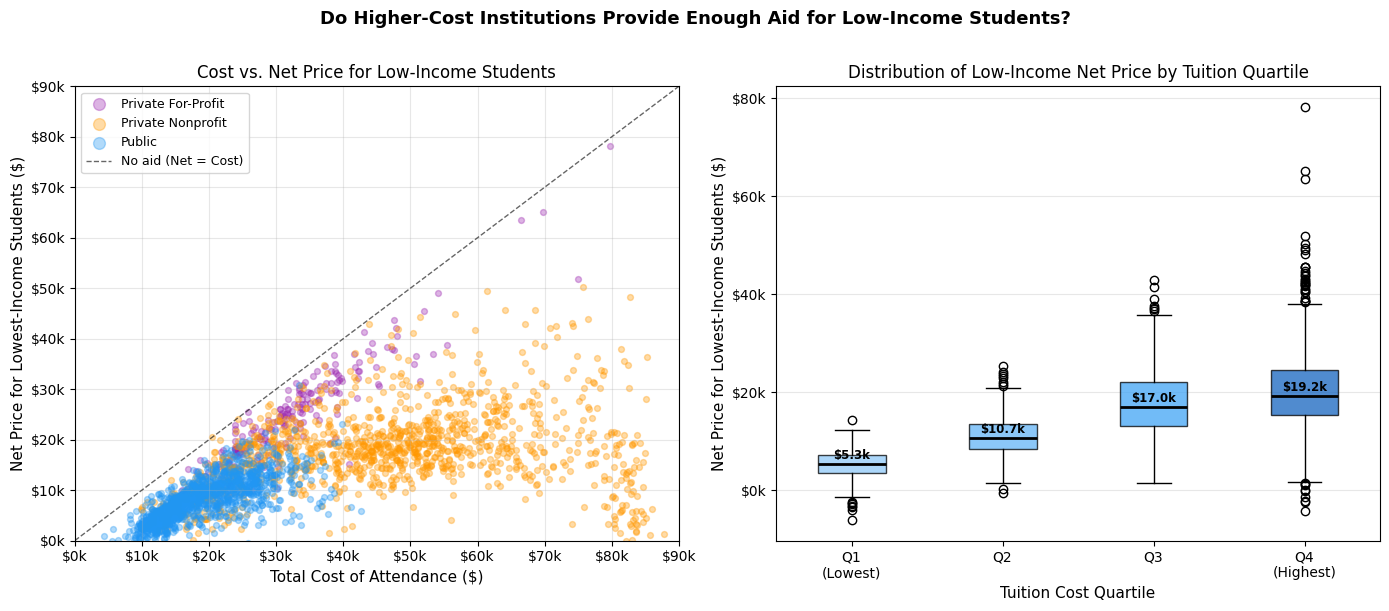

In [ ]:
# Visualization for Dataset 2
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Do Higher-Cost Institutions Provide Enough Aid for Low-Income Students?",
    fontsize=13,
    fontweight="bold",
    y=1.01
)

colors = {
    "Public": "#2196F3",
    "Private Nonprofit": "#FF9800",
    "Private For-Profit": "#9C27B0"
}

# LEFT: Scatter plot of cost vs low-income net price
ax1 = axes[0]
for itype, group in df.dropna(subset=["NPT41"]).groupby("inst_type"):
    ax1.scatter(
        group["COSTT4_A"],
        group["NPT41"],
        alpha=0.35,
        s=18,
        label=itype,
        color=colors[itype]
    )

# 45-degree line where net price equals full cost
lim = [0, 90000]
ax1.plot(lim, lim, "k--", linewidth=1, label="No aid (Net = Cost)", alpha=0.6)
ax1.set_xlim(lim)
ax1.set_ylim(lim)
ax1.set_xlabel("Total Cost of Attendance ($)", fontsize=11)
ax1.set_ylabel("Net Price for Lowest-Income Students ($)", fontsize=11)
ax1.set_title("Cost vs. Net Price for Low-Income Students", fontsize=12)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax1.legend(fontsize=9, markerscale=2)
ax1.grid(True, alpha=0.3)

# RIGHT: Box plot of low-income net price by tuition quartile
ax2 = axes[1]
quartile_groups = [
    df[df["tuition_quartile"] == q]["NPT41"].dropna().values
    for q in ["Q1\n(Lowest)", "Q2", "Q3", "Q4\n(Highest)"]
]

bp = ax2.boxplot(
    quartile_groups,
    patch_artist=True,
    notch=False,
    medianprops=dict(color="black", linewidth=2)
)

box_colors = ["#90CAF9", "#64B5F6", "#42A5F5", "#1565C0"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax2.set_xticklabels(["Q1\n(Lowest)", "Q2", "Q3", "Q4\n(Highest)"])
ax2.set_xlabel("Tuition Cost Quartile", fontsize=11)
ax2.set_ylabel("Net Price for Lowest-Income Students ($)", fontsize=11)
ax2.set_title("Distribution of Low-Income Net Price by Tuition Quartile", fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax2.grid(True, alpha=0.3, axis="y")

# Add median labels to each box
for i, vals in enumerate(quartile_groups):
    med = np.median(vals)
    ax2.text(i + 1, med + 400, f'${med/1000:.1f}k', ha='center', va='bottom',
             fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()

## Visualization Explanation

These visualizations are important because they show both the **average pattern** and the **variation across institutions**.

The scatter plot directly compares total cost of attendance with what the lowest-income students actually pay. Institutions closer to the diagonal “no aid” line are not substantially reducing costs for low-income students. The box plot complements this by showing how the entire distribution of low-income net price shifts upward as schools become more expensive.

Together, the visuals suggest that although more expensive schools often provide larger aid discounts, low-income students still tend to face a higher net price at those institutions. That makes Dataset 2 highly relevant to our project because it helps explain how tuition and aid interact to shape affordability.

### Challenges with Dataset 2

One challenge is that a large share of institutions do not report complete net price information, so some of the summary statistics represent only the subset of schools with available data. Another challenge is that public and private institutions report different net price variables, which required us to combine them into unified columns. Even so, the dataset still provides useful evidence about how affordability differs across institutions.

# Dataset 3: National Center for Education Statistics (NCES)

**Source:** https://nces.ed.gov/programs/digest/d23/tables/dt23_330.30.asp

This dataset contains historical tuition data across different types of colleges and universities in the United States.

### Key Question

**How much have tuition costs increased over time across different types of institutions?**

The dataset includes academic-year observations for multiple institution categories, allowing us to study how tuition has evolved across public, nonprofit, and for-profit colleges.

In [ ]:
# Load raw NCES dataset
raw_nces = pd.read_csv("nces.csv", encoding="latin-1", header=None)

# Preview raw data
raw_nces.head(12)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,"Table 330.30. Average undergraduate tuition, f...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Control and level of institution, and academic...",Current dollars,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Constant 2022-23 dollars\1\,NaN,NaN,NaN,NaN
2,NaN,"Tuition, fees, room, and board",NaN,NaN,NaN,NaN,Tuition and required fees,NaN,NaN,NaN,NaN,Tuition and required fees,NaN,NaN,NaN,NaN
3,NaN,10th per-\ncentile,25th per-\ncentile,Median (50th percen-\ntile),75th per-\ncentile,90th per-\ncentile,10th per-\ncentile,25th per-\ncentile,Median (50th percen-\ntile),75th per-\ncentile,90th per-\ncentile,10th per-\ncentile,25th per-\ncentile,Median (50th percen-\ntile),75th per-\ncentile,90th per-\ncentile
4,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
5,Public institutions\2\,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2000-01,"$5,741","$6,880","$8,279","$9,617","$11,384",$612,"$1,480","$2,403","$3,444","$4,583","$1,047","$2,533","$4,113","$5,895","$7,844"
7,2005-06,"7,700","9,623","11,348","13,543","16,264",990,"2,070","3,329","5,322","6,972","1,491","3,117","5,014","8,015","10,500"
8,2010-11,"9,889","12,856","15,234","17,860","21,593","1,230","2,626","4,632","7,115","9,420","1,667","3,560","6,279","9,644","12,769"
9,2015-16,"13,215","15,947","18,648","21,735","25,180","1,632","3,456","6,452","9,326","11,948","2,053","4,347","8,115","11,730","15,027"


## Tidy Data / Cleaning

The raw NCES dataset includes title rows and formatting elements because it was originally designed as a published table rather than a machine-readable dataset.

To make it usable for analysis, we:

- isolate the rows containing academic years and institution types
- carry institution labels to each year observation
- rename columns clearly
- convert tuition values to numeric format
- drop rows containing missing values

These steps transform the published table into a tidy dataset where each row represents an institution type in a specific academic year.

In [ ]:
# Keep only the portion of the table containing institution labels and year rows
nces_subset = raw_nces.iloc[5:67, [0, 6, 7, 8, 9, 10]].copy()

# Rename selected columns
nces_subset.columns = [
    "label",
    "p10_tuition",
    "p25_tuition",
    "median_tuition",
    "p75_tuition",
    "p90_tuition"
]

# Build a tidy dataset by carrying the institution type label to each year row
records = []
current_type = None

for _, row in nces_subset.iterrows():
    label = str(row["label"]).strip()

    if re.match(r'^\d{4}-\d{2}$', label):
        records.append({
            "year": label,
            "institution_type": current_type,
            "p10_tuition": row["p10_tuition"],
            "p25_tuition": row["p25_tuition"],
            "median_tuition": row["median_tuition"],
            "p75_tuition": row["p75_tuition"],
            "p90_tuition": row["p90_tuition"]
        })
    else:
        current_type = label

nces_df = pd.DataFrame(records)

# Clean institution type labels
nces_df["institution_type"] = (
    nces_df["institution_type"]
    .str.replace(r'\\\d.*?\\', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Convert tuition columns to numeric
tuition_cols = ["p10_tuition", "p25_tuition", "median_tuition", "p75_tuition", "p90_tuition"]

for col in tuition_cols:
    nces_df[col] = (
        nces_df[col]
        .astype(str)
        .str.replace(r'[$, ]', '', regex=True)
    )
    nces_df[col] = pd.to_numeric(nces_df[col], errors="coerce")

# Drop rows with missing values
nces_df = nces_df.dropna().reset_index(drop=True)

# Display cleaned dataset
nces_df.head()

NameError: name 're' is not defined

In [ ]:
# Display missing values and dtypes
print("Missing values after cleaning:")
print(nces_df.isna().sum())

print("\nData types after cleaning:")
print(nces_df.dtypes)

The `year` variable remains stored as an object data type because academic years are recorded as labels such as **2000-01** and **2022-23**, rather than single numeric values. The tuition variables were converted to numeric data types so they can be used in summary statistics and visualizations.

## Exploratory Data Analysis

We examine summary statistics for the tuition columns and then visualize how median tuition changes across institution types over time.

In [ ]:
# Summary statistics for tuition percentiles
nces_df[tuition_cols].describe()

The NCES summary statistics show that tuition varies substantially across institution types and time periods.

The **mean median tuition** is about **\$13,821**, which gives a broad sense of the typical tuition level across the full dataset. The **minimum median tuition** is **\$1,387**, while the **maximum median tuition** is **\$39,570**, showing that the cost of college differs dramatically depending on the type of institution.

The **standard deviation of median tuition**, about **\$10,095**, is also large, which indicates substantial variation in college costs. This variation matters because students do not all face the same price when considering higher education.

The spread between lower and higher tuition percentiles is also meaningful. For example, the **mean 10th-percentile tuition** is about **\$6,728**, while the **mean 90th-percentile tuition** is about **\$21,753**. This difference shows that even within broad institution categories, tuition is unevenly distributed.

Together, these statistics support the idea that college costs are both **rising over time** and **highly uneven across institution types**, which is directly relevant to our project on affordability and access.

In [ ]:
# Visualize median tuition over time by institution type
plt.figure(figsize=(12, 7))

for inst in nces_df["institution_type"].unique():
    subset = nces_df[nces_df["institution_type"] == inst]
    plt.plot(subset["year"], subset["median_tuition"], marker="o", label=inst)

plt.title("Median Tuition Over Time by Institution Type", fontsize=16)
plt.xlabel("Academic Year", fontsize=12)
plt.ylabel("Median Tuition and Required Fees (USD)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Visualization Explanation

This line chart shows how median tuition and required fees have changed over time for different types of institutions. The figure is useful because it makes it easy to compare both the **level of tuition** and the **rate of increase** across institution categories.

This visualization directly addresses our Dataset 3 question: **How much have tuition costs increased over time across different types of institutions?** It also supports the larger project by showing that rising college costs are not uniform. Instead, the cost burden students face depends heavily on where they enroll.

## Milestone 1 Reflection

Across these three datasets, we see early evidence that college affordability and enrollment inequality are strongly connected. Dataset 1 suggests that students from higher-income households are much more likely to enroll in college. Dataset 2 shows that higher-cost institutions do not always reduce net price enough to make themselves equally accessible to lower-income students. Dataset 3 demonstrates that tuition has increased substantially over time across institution types.

Together, these datasets provide a strong foundation for the rest of the project, where we hope to further connect rising college costs to unequal access to higher education.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%%shell
jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/julieandliv.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/julieandliv.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 729123 bytes to /content/drive/MyDrive/Colab Notebooks/julieandliv.html
